In [10]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import cmasher as cmr

from astropy.constants import G
import astropy.units as u

import pandas as pd

import gala.potential as gp
from gala.units import galactic

In [2]:
ro,vo=8.178,228. # rotation curve not constant so this is an approx

Msat = 8e10 * u.Msun
asat = 8*u.kpc

In [3]:
dat_ = pd.read_csv('../../data/S1-orbit.txt', sep=' ', names=['x', 'y', 'z', 'Rxy', 'R', 'vx', 'vy', 'vz', 'A', 'B'])
dat=dat_[(dat_.index<5.5) & (dat_.index>2.)]

In [4]:
def instantaneous_accel_from_sat(Jphi, thetaphi, time):
    # time must be an index of the sim data file
    
    R_region = Jphi / vo
    z_region = 0.0  # midplane

    # Satellite position as function of time
    x_sat = np.array(dat.loc[time].x) * u.kpc
    y_sat = np.array(dat.loc[time].y) * u.kpc
    z_sat = np.array(dat.loc[time].z) * u.kpc

    # Region position (cylindrical to cartesian)
    x_region = (R_region * np.cos(thetaphi)) * u.kpc
    y_region = (R_region * np.sin(thetaphi)) * u.kpc
    z_region = 0.0 * u.kpc # fixed midplane for now

    # Relative position vector
    dx = x_sat - x_region
    dy = y_sat - y_region
    dz = z_sat - z_region

    r_vec = np.vstack([dx, dy, dz])
    r_mag = np.linalg.norm(r_vec, axis=0)

    # Hernquist acceleration magnitude
    M_enc = gp.HernquistPotential(m=Msat, c=asat, units=galactic).mass_enclosed(r_vec)
    a_mag = G * M_enc / r_mag**3  # in kpc/Gyr^2

    # z-component of acceleration
    a_z = (a_mag * dz).to(u.km/u.s**2)  # direction-aware vertical accel
    
    return a_z, a_mag

In [5]:
# To get colorbar
jphi_c = np.linspace(1000, 4000, 31)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

In [6]:
a_z, a_mag = instantaneous_accel_from_sat(2000, 0, np.array(dat.index))

In [63]:
np.sum(all_azs[:30,:,:], axis=0).shape

(16, 31)

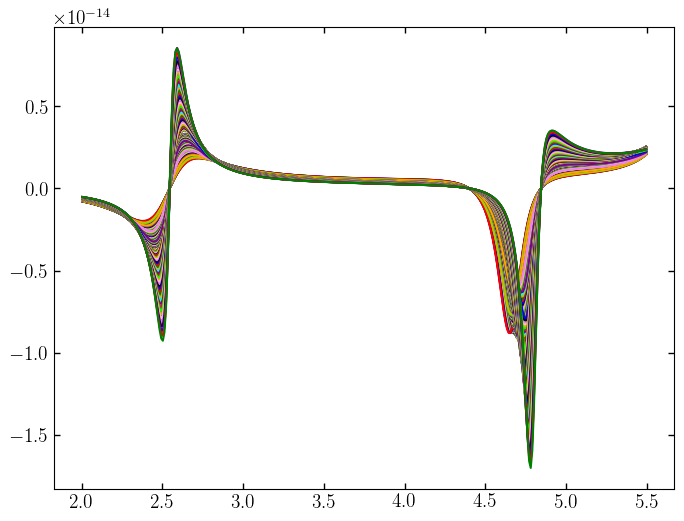

In [7]:
all_azs = np.zeros((len(dat.index), len(tphi_c), len(jphi_c)))

for ind1, ind2 in np.ndindex(T.shape):
    a_z, _ = instantaneous_accel_from_sat(J[ind1,ind2], T[ind1,ind2], np.array(dat.index))
    all_azs[:,ind1,ind2] = a_z
    plt.plot(dat.index, a_z)

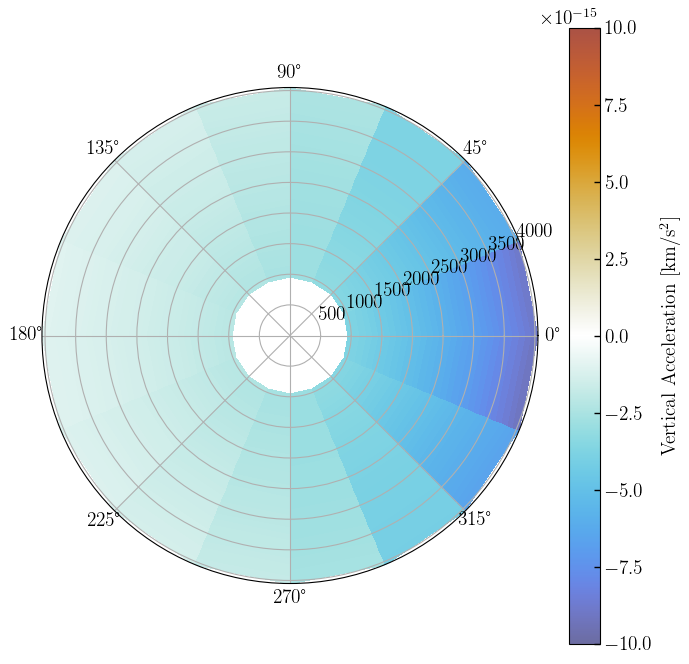

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': 'polar'})
im = ax.pcolormesh(T, J, np.reshape(all_azs[50], T.shape, 'F'), cmap=cmr.prinsenvlag_r, vmin=-1e-14, vmax=1e-14)
cb = fig.colorbar(im)
cb.set_label(r'Vertical Acceleration [km/s$^2$]')

In [77]:
fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[0.75,1])
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])                      # Time vs J
ax3 = fig.add_subplot(gs[1,0], projection='polar')   
ax4 = fig.add_subplot(gs[1,1], projection='polar')   
cmap = cmr.prinsenvlag_r

ax1.plot(dat.x, dat.z, label='orbit')
ax1.plot([-20,20],[0,0], c='b', lw=10, label='disk')
im1,  = ax1.plot([], [], 'ro')
ax1.set_xlim(-100,100) ; ax1.set_ylim(-100,100)
ax1.set_xlabel(r'$x$ [kpc]') ; ax1.set_ylabel(r'$z$ [kpc]')
ax1.set_aspect('equal')
ax1.legend(loc='lower right')

ax2.plot(dat.index,dat.x,label='x (kpc)',color='blue')
ax2.plot(dat.index,dat.y,label='y (kpc)',color='red')
ax2.plot(dat.index,dat.z,label='z (kpc)',color='green')
ax2.set_xlabel(r'$\mathrm{Time\ (Gyr)}$')
ax2.set_ylabel(r'$x,y,z\ (\mathrm{kpc})$')
# ax1.set_xlim(2,5)
ax2.set_ylim(-100, 100)
ax2.legend(loc='lower right')

im2 = ax2.axvline(dat.index[0], ls='--', c='k')

im3 = ax3.pcolormesh(T, J, np.reshape(all_azs[0], T.shape, order='F'), 
                   cmap=cmap, norm=mpl.colors.SymLogNorm(vmin=-2e-14, vmax=2e-14, linthresh=2e-15))
cb = fig.colorbar(im3)
cb.set_label(r'Vertical Acceleration [km/s$^2$]')
ax3.set_title(r'Instantaneous acceleration')


im4 = ax4.pcolormesh(T, J, np.reshape(all_azs[0], T.shape, order='F'), 
                     cmap=cmap, norm=mpl.colors.SymLogNorm(vmin=-1e-13, vmax=1e-13, linthresh=2e-15))
cb2 = fig.colorbar(im4)
cb2.set_label(r'Vertical Acceleration [km/s$^2$]')
ax4.set_title(r'Cumulative acceleration')

for ax in [ax3,ax4]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=4000$'])
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True,
                    labelbottom = False, bottom = False)      
    ax.grid(visible=False)
    ax.set_rlabel_position(50)

title = fig.suptitle(f"Time = {dat.index[0]:.2f} Gyr")
fig.tight_layout()

def update(frame):
    im4.set_array(np.reshape(np.sum(all_azs[:frame,:,:], axis=0), T.shape, order='F').ravel())
    im3.set_array(np.reshape(all_azs[frame], T.shape, order='F').ravel())
    im2.set_xdata([frame*0.009778 + dat.index[0], frame*0.009778 + dat.index[0]])
    im1.set_data([dat.loc[dat.index[frame]].x], [dat.loc[dat.index[frame]].z])
    title.set_text(f"Time = {dat.index[frame]:.2f} Gyr")
    return [im1, im2, im3, im4]

# Create animation
ani = FuncAnimation(fig, update, frames=len(all_azs), interval=100, blit=True)
writer = animation.FFMpegWriter(fps=10, metadata=dict(artist='Kiyan Tavangar'), bitrate=1800)
ani.save("../../figures/B2_figures/vertical_acceleration.mp4", writer=writer)
# plt.show()
plt.close(fig)